# CSE 445 — Computer Vision
## Part B — Notebook 4a: DINOv3-guided Distillation into YOLOv26

| | |
|---|---|
| **Group Number** | `02` |
| **Instructor** | Dr. Mohammad Rifat Ahmmad Rashid, Associate Professor, Dept. of CSE, EWU |

| Name | ID |
|---|---|
| MD SHAFIN AHAMED SIAM | 2023-1-60-007 |
| ALBIN ISRAT SIDDIQUE | 2023-1-60-212 |
| Md. Ariful Islam Opi | 2023-1-60-141 |
| Nasrullah Kaisher Sijan | 2023-1-60-204 |

| Property | Value |
|---|---|
| **Dataset** | KIIT-MiTA — High-Resolution Drone Imagery for Military Object Detection and Recognition. |
| **Source** | https://data.mendeley.com/datasets/drjmrf5kk5/1 |
| **Model** |  DINOv3 PRETRAIN |
---

### DINOv3-guided distillation

DINOv3 and YOLOv26 are different architectures with incompatible tensors — nothing is copied directly.
Instead, an official, frozen, large-scale-pretrained **DINOv3 ViT-B/16 teacher** guides a small YOLOv26n
**student** via `lightly-train`: the student is trained so its own features match the frozen teacher's
features on the same unlabelled images. This is fundamentally different from BYOL/SimCLR/I-JEPA's
from-scratch protocol — the teacher already saw hundreds of millions of images, so this is
**domain-adaptive pretraining**, not a like-for-like from-scratch comparison, and is discussed as such in
the report. The output is **already a full YOLO detector checkpoint** — Notebook 4b loads it directly,
skipping the weight-surgery/transfer step used for the other three methods.

## 1. Install `lightly-train` and `ssldet` (in this order), then imports

In [1]:
%pip install -q -U "lightly-train[ultralytics]>=0.16.2"
%pip install -q --no-cache-dir --force-reinstall --no-deps "git+https://github.com/rifat963/ssl-detection-lab.git@main"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 975.0/975.0 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 891.2/891.2 kB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 63.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.6/165.6 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.8/155.8 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.4/61.4 kB 4.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import json
import random
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from packaging.version import Version
from PIL import Image
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from tqdm.auto import tqdm
from ultralytics import YOLO
import lightly_train

import ssldet
from ssldet import DINOv3YOLOConfig, pretrain_dinov3_yolo26, validate_dinov3_yolo26_support
from ssldet.backbones import YOLOBackboneEncoder
from ssldet.data import IMAGENET_MEAN, IMAGENET_STD, UnlabeledImageDataset

random.seed(0); np.random.seed(0); torch.manual_seed(0); torch.cuda.manual_seed_all(0)
torch.set_float32_matmul_precision("high")
sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore", message=r".*isinstance\(treespec, LeafSpec\).*deprecated.*", category=FutureWarning)

REQUIRED_SSLDET_VERSION = "0.8.1"
assert Version(ssldet.__version__) >= Version(REQUIRED_SSLDET_VERSION), (
    f"ssldet {ssldet.__version__} found, need >= {REQUIRED_SSLDET_VERSION}. "
    "Restart the kernel/session and rerun the install cell from the top, then re-run this cell."
)
print("ssl-detection-lab version:", ssldet.__version__)
print("lightly-train version:", getattr(lightly_train, "__version__", "unknown"))
assert torch.cuda.is_available(), "Select a GPU accelerator before continuing."

GPU_COUNT = torch.cuda.device_count()
DEVICE = torch.device("cuda:0")
print("GPUs:", GPU_COUNT)

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
ssl-detection-lab version: 0.9.0
lightly-train version: 0.17.0
GPUs: 2


## 2. Attach the Part B data-prep output (partition + SSL pool, already built)

In [3]:
import pathlib, json, yaml

_manifest_candidates = list(pathlib.Path("/kaggle/input").rglob("partition_manifest.json"))
if not _manifest_candidates:
    raise FileNotFoundError(
        "No partition_manifest.json found under /kaggle/input. "
        "Attach group02-partB-00-data-prep's output as an input to this notebook."
    )
PARTITION_MANIFEST_PATH = _manifest_candidates[0]
partition_manifest = json.loads(PARTITION_MANIFEST_PATH.read_text())
BASE_DIR = PARTITION_MANIFEST_PATH.parent

SEED = partition_manifest["seed"]
CLASS_NAMES = partition_manifest["class_names"]
NUM_CLASSES = len(CLASS_NAMES)

RESPLIT_ROOT = BASE_DIR / "dataset-resplit"
SSL_POOL_TRAIN_DIR = RESPLIT_ROOT / "train" / "images"
SSL_POOL_VAL_DIR = RESPLIT_ROOT / "val" / "images"
SSL_POOL_TEST_DIR = RESPLIT_ROOT / "test" / "images"

for d in [SSL_POOL_TRAIN_DIR, SSL_POOL_VAL_DIR, SSL_POOL_TEST_DIR]:
    if not d.exists():
        raise FileNotFoundError(f"Expected directory missing: {d}")

stems_train = partition_manifest["stems_ssl_pool_raw"]
stems_val = partition_manifest["stems_val"]
stems_test = partition_manifest["stems_test"]

print("SSL pool (train) dir:", SSL_POOL_TRAIN_DIR, "| raw stems:", len(stems_train))
print("Val dir             :", SSL_POOL_VAL_DIR, "| stems:", len(stems_val))
print("Test dir            :", SSL_POOL_TEST_DIR, "| stems:", len(stems_test))
print("Classes:", CLASS_NAMES)

SSL pool (train) dir: /kaggle/input/notebooks/arifulislamopi/group02-dataset-eda/dataset-resplit/train/images | raw stems: 1339
Val dir             : /kaggle/input/notebooks/arifulislamopi/group02-dataset-eda/dataset-resplit/val/images | stems: 164
Test dir            : /kaggle/input/notebooks/arifulislamopi/group02-dataset-eda/dataset-resplit/test/images | stems: 178
Classes: ['Artilary', 'Missile', 'Radar', 'M. Rocket Launcher', 'Soldier', 'Tank', 'Vehicle']


## 3. DINOv3 teacher checkpoint and distillation support — fail fast if missing

The configuration requires the attached local DINOv3 ViT-B/16 checkpoint. It does not silently fall
back to downloading teacher weights — if the Kaggle dataset input is missing, this cell raises a clear
error immediately rather than failing deep inside training.


In [4]:
DINOV3_MODEL = "dinov3/vitb16"
DINOV3_WEIGHTS = "/kaggle/input/datasets/mrifatrashid/dinov3-weigths/dinov3_vitb16_pretrain_lvd1689m-73cec8be.pth"
YOLO_STUDENT = "ultralytics/yolo26n.yaml"

if not DINOV3_WEIGHTS.startswith(("http://", "https://")):
    assert Path(DINOV3_WEIGHTS).is_file(), (
        f"DINOv3 teacher weights not found at {DINOV3_WEIGHTS}. "
        "Attach the mrifatrashid/dinov3-weigths Kaggle dataset as an input to this notebook."
    )

support = validate_dinov3_yolo26_support(lightly_train, teacher_model=DINOV3_MODEL, student_model=YOLO_STUDENT)
pd.Series({
    "teacher available": support[DINOV3_MODEL],
    "student available": support[YOLO_STUDENT],
    "distillation available": support["distillation"],
    "teacher weights MB": round(Path(DINOV3_WEIGHTS).stat().st_size / 1024 ** 2, 2),
})

teacher available           True
student available           True
distillation available      True
teacher weights MB        326.98
dtype: object

## 4. Inspect the dataset

Total image counts per split, a per-class instance-count table across all three splits, and a sample
grid of raw training images.


In [5]:
IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
def image_files(directory):
    return sorted(p for p in Path(directory).rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_SUFFIXES)

train_images = image_files(SSL_POOL_TRAIN_DIR)
val_images = image_files(SSL_POOL_VAL_DIR)
test_images = image_files(SSL_POOL_TEST_DIR)

pd.Series({
    "train — raw stems (pre copy-paste)": len(stems_train),
    "train — on disk (raw + copy-paste)": len(train_images),
    "train — copy-paste synthetic added": len(train_images) - len(stems_train),
    "val — on disk (always raw, never augmented)": len(val_images),
    "test — on disk (always raw, never augmented)": len(test_images),
    "TOTAL images on disk (train + val + test)": len(train_images) + len(val_images) + len(test_images),
})

train — raw stems (pre copy-paste)              1339
train — on disk (raw + copy-paste)              2377
train — copy-paste synthetic added              1038
val — on disk (always raw, never augmented)      164
test — on disk (always raw, never augmented)     178
TOTAL images on disk (train + val + test)       2719
dtype: int64

In [6]:
def count_class_instances(labels_dir):
    counts = Counter()
    for lbl_path in Path(labels_dir).glob("*.txt"):
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    counts[int(float(parts[0]))] += 1
    return counts

train_label_counts = count_class_instances(RESPLIT_ROOT / "train" / "labels")
val_label_counts = count_class_instances(RESPLIT_ROOT / "val" / "labels")
test_label_counts = count_class_instances(RESPLIT_ROOT / "test" / "labels")

class_table = pd.DataFrame({
    "train (raw+copy-paste)": [train_label_counts.get(i, 0) for i in range(NUM_CLASSES)],
    "val": [val_label_counts.get(i, 0) for i in range(NUM_CLASSES)],
    "test": [test_label_counts.get(i, 0) for i in range(NUM_CLASSES)],
}, index=CLASS_NAMES)
class_table["total"] = class_table.sum(axis=1)
class_table.index.name = "class name"
class_table

,train (raw+copy-paste),val,test,total
class name,,,,
Artilary,610,29,28,667
Missile,764,40,45,849
Radar,772,33,29,834
M. Rocket Launcher,705,33,36,774
Soldier,937,113,92,1142
Tank,824,81,94,999
Vehicle,1033,93,159,1285


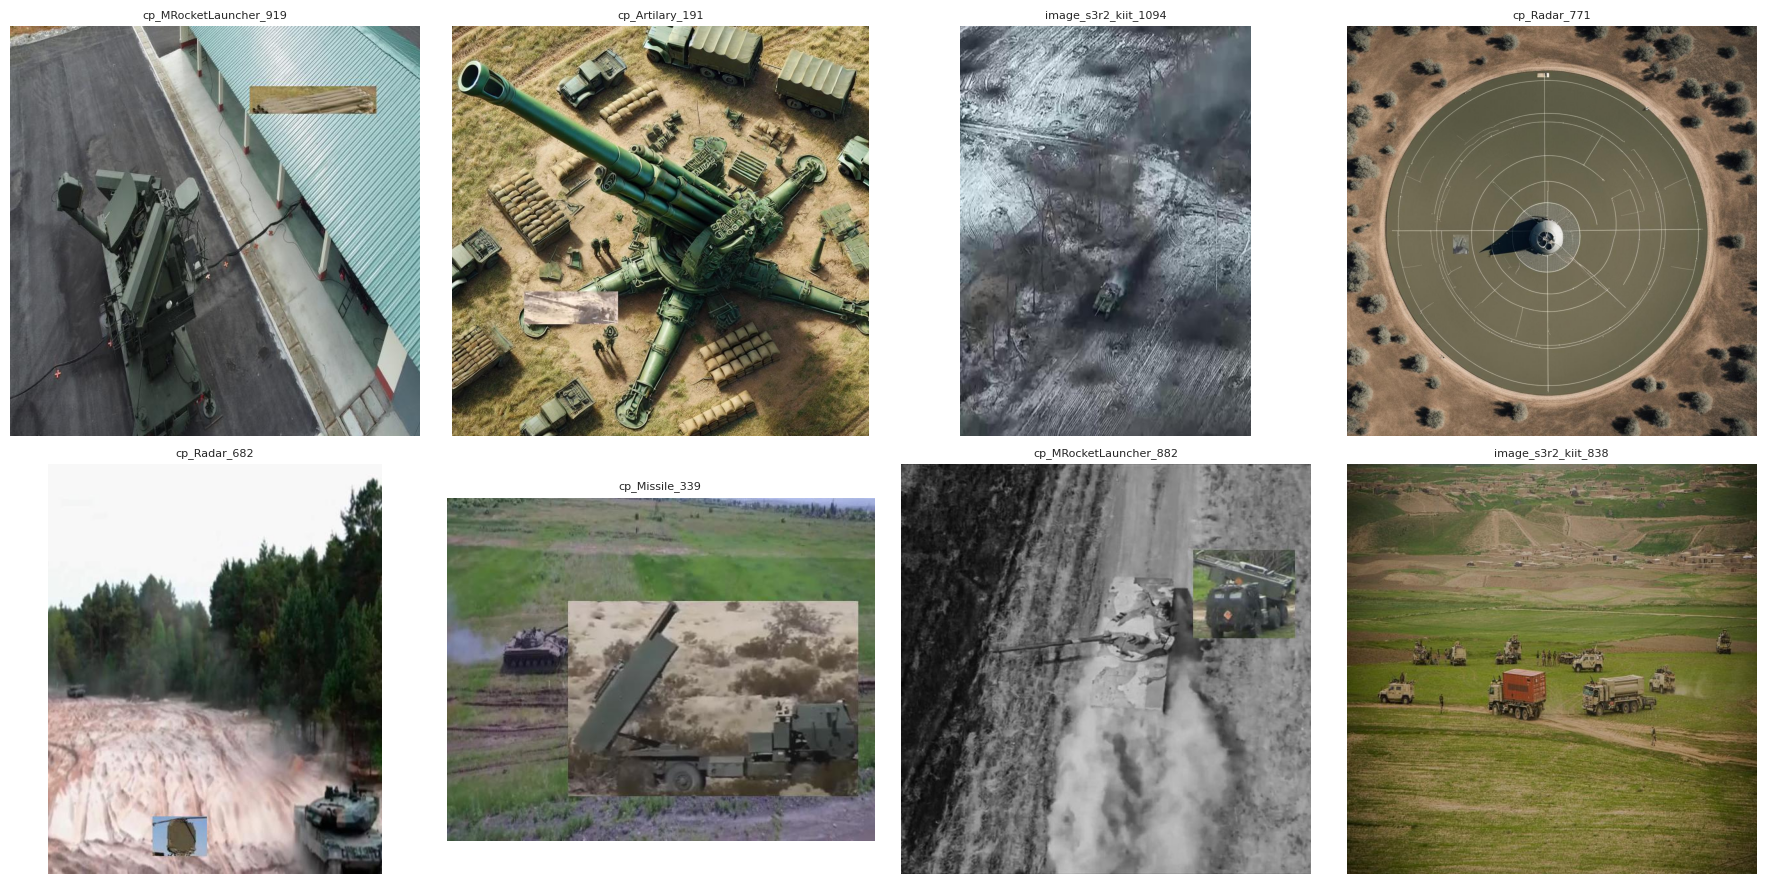

In [7]:
sample_train_paths = random.Random(SEED).sample(train_images, min(8, len(train_images)))
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, p in zip(axes.flat, sample_train_paths):
    ax.imshow(Image.open(p))
    ax.set_title(p.stem[:28], fontsize=8)
    ax.axis("off")
plt.tight_layout(); plt.show()

## 5. DINOv3-to-YOLOv26 distillation config 200 epochs, matching the shared budget



In [8]:
METHOD = "dinov3"
PRETRAIN_OUTPUT_DIR = f"/kaggle/working/{METHOD}_kiitmita"

config = DINOv3YOLOConfig(
    data=str(SSL_POOL_TRAIN_DIR),
    output_dir=PRETRAIN_OUTPUT_DIR,
    teacher_weights=DINOV3_WEIGHTS,
    teacher_model="dinov3/vitb16",
    student_model="ultralytics/yolo26n.yaml",
    epochs=200,
    batch_size=32,
    image_size=224,
    num_workers=2,
    accelerator="gpu",
    precision="16-mixed",
    seed=42,
    extra_arguments={
        "trainer_args": {
            "enable_model_summary": False,
        },
        "optim": "adamw",
        "optim_args": {
            "lr": 3e-4,
            "weight_decay": 1e-4,
            "betas": (0.9, 0.999),
            "eps": 1e-8,
        },
    },
).validate()

pd.Series({
    "student": config.student_model, "teacher": config.teacher_model, "epochs": config.epochs,
    "unlabelled images": len(train_images), "batch size": config.batch_size,
    "image size": config.image_size, "precision": config.precision,
})

student              ultralytics/yolo26n.yaml
teacher                         dinov3/vitb16
epochs                                    200
unlabelled images                        2377
batch size                                 32
image size                                224
precision                            16-mixed
dtype: object

## 6. Preview the label-free training input

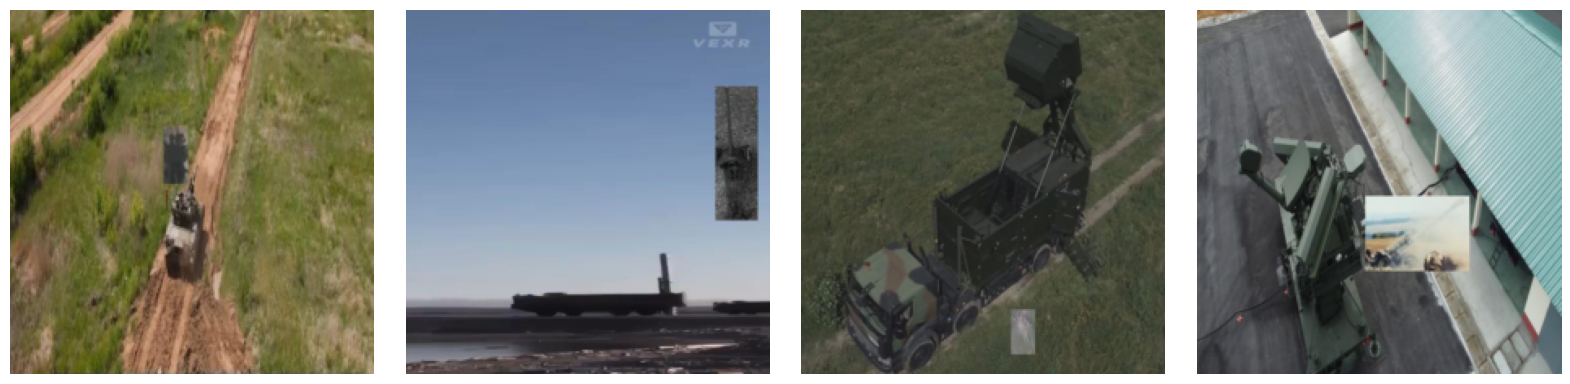

In [9]:
from torchvision.transforms import v2

preview_transform = v2.Compose([
    v2.Resize((config.image_size, config.image_size), antialias=True),
    v2.ToImage(), v2.ToDtype(torch.float32, scale=True), v2.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
preview_dataset = UnlabeledImageDataset(train_images, preview_transform)
mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for index, axis in enumerate(axes):
    tensor = preview_dataset[index]
    axis.imshow((tensor * std + mean).clamp(0, 1).permute(1, 2, 0))
    axis.axis("off")
plt.tight_layout(); plt.show()

## 7. Run DINOv3-guided distillation (200 epochs, both T4s)

In [10]:
training_result = pretrain_dinov3_yolo26(config, module=lightly_train)
training_result

Args: {
    "accelerator": "gpu",
    "batch_size": 32,
    "callbacks": null,
    "checkpoint": null,
    "data": "/kaggle/input/notebooks/arifulislamopi/group02-dataset-eda/dataset-resplit/train/images",
    "devices": 1,
    "embed_dim": null,
    "epochs": 200,
    "float32_matmul_precision": "auto",
    "loader_args": null,
    "loggers": null,
    "method": "distillation",
    "method_args": {
        "teacher": "dinov3/vitb16",
        "teacher_weights": "/kaggle/input/datasets/mrifatrashid/dinov3-weigths/dinov3_vitb16_pretrain_lvd1689m-73cec8be.pth"
    },
    "model": "ultralytics/yolo26n.yaml",
    "model_args": null,
    "num_nodes": 1,
    "num_workers": 2,
    "optim": "adamw",
    "optim_args": {
        "betas": [
            0.9,
            0.999
        ],
        "eps": 1e-08,
        "lr": 0.0003,
        "weight_decay": 0.0001
    },
    "out": "/kaggle/working/dinov3_kiitmita",
    "overwrite": true,
    "precision": "16-mixed",
    "resume": null,
    "resume_int

Training: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/core/module.py:1333: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate

`Trainer.fit` stopped: `max_epochs=200` reached.
Training completed.
Example: How to use the exported model
----------------------------------------------------------------------------------------
from ultralytics import YOLO

# Load the pretrained model
model = YOLO('/kaggle/working/dinov3_kiitmita/exported_models/exported_last.pt')

# Finetune or evaluate the model
...
----------------------------------------------------------------------------------------

Model exported.


DINOv3YOLOResult(output_dir=PosixPath('/kaggle/working/dinov3_kiitmita'), training_checkpoint=PosixPath('/kaggle/working/dinov3_kiitmita/checkpoints/last.ckpt'), yolo_checkpoint=PosixPath('/kaggle/working/dinov3_kiitmita/exported_models/exported_last.pt'), metrics_jsonl=PosixPath('/kaggle/working/dinov3_kiitmita/metrics.jsonl'), teacher_model='dinov3/vitb16', teacher_weights=PosixPath('/kaggle/input/datasets/mrifatrashid/dinov3-weigths/dinov3_vitb16_pretrain_lvd1689m-73cec8be.pth'), student_model='ultralytics/yolo26n.yaml')

## 8. Review loss and checkpoints

,lr-AdamW/params,lr-AdamW/params_no_weight_decay,step,train_loss,train_loss/local_loss,train_loss/global_loss,profiling/batch_time,profiling/data_time,epoch
587,NaN,NaN,14699,2.972079,0.446498,2.525581,0.156049,0.016572,198.0
588,4.465127e-08,4.465127e-08,14749,NaN,NaN,NaN,NaN,NaN,NaN
589,NaN,NaN,14749,2.768925,0.425370,2.343555,0.163473,0.013473,199.0
590,4.330127e-08,4.330127e-08,14799,NaN,NaN,NaN,NaN,NaN,NaN
591,NaN,NaN,14799,3.668308,0.496084,3.172225,0.156223,0.014214,199.0


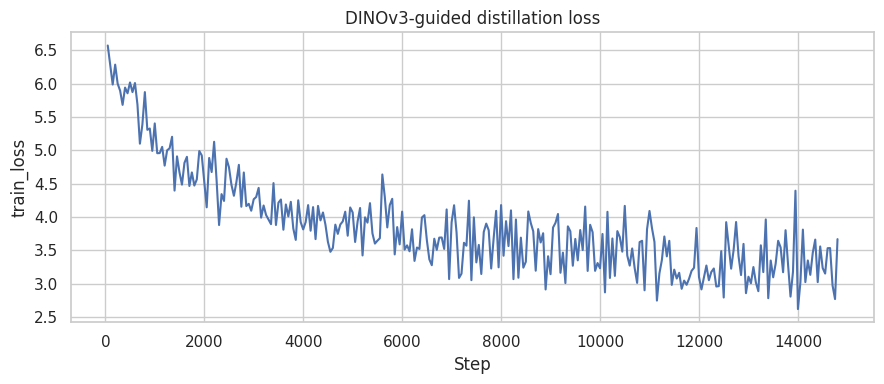

Lightly checkpoint         /kaggle/working/dinov3_kiitmita/checkpoints/la...
YOLO student checkpoint    /kaggle/working/dinov3_kiitmita/exported_model...
teacher                                                        dinov3/vitb16
teacher weights            /kaggle/input/datasets/mrifatrashid/dinov3-wei...
unlabelled images                                                       2377
dtype: object

In [11]:
YOLO_CHECKPOINT = training_result.yolo_checkpoint
LIGHTLY_CHECKPOINT = training_result.training_checkpoint

metrics_records = []
if training_result.metrics_jsonl.is_file():
    for line in training_result.metrics_jsonl.read_text().splitlines():
        if line.strip():
            metrics_records.append(json.loads(line))
metrics_frame = pd.json_normalize(metrics_records)
if not metrics_frame.empty:
    display(metrics_frame.tail())

    loss_col = next((c for c in metrics_frame.columns if "loss" in c.lower()), None)
    if loss_col is not None:
        x_col = "step" if "step" in metrics_frame.columns else metrics_frame.columns[0]
        loss_series = metrics_frame[[x_col, loss_col]].dropna().sort_values(x_col)
    
        fig, ax = plt.subplots(figsize=(9, 4))
        sns.lineplot(data=loss_series, x=x_col, y=loss_col, linewidth=1.5, errorbar=None, ax=ax)
        ax.set_title("DINOv3-guided distillation loss")
        ax.set_xlabel("Step")
        ax.set_ylabel(loss_col)
        plt.tight_layout()
        plt.show()

pd.Series({
    "Lightly checkpoint": str(LIGHTLY_CHECKPOINT), "YOLO student checkpoint": str(YOLO_CHECKPOINT),
    "teacher": training_result.teacher_model, "teacher weights": str(training_result.teacher_weights),
    "unlabelled images": len(train_images),
})

## 9. Extract validation features

Embed every validation image with the trained YOLO student backbone. Validation images are always 100%
raw (never copy-paste-augmented), so this is a clean generalisation check.


In [12]:
infer_tf = v2.Compose([v2.Resize((config.image_size, config.image_size)), v2.ToImage(),
                        v2.ToDtype(torch.float32, scale=True), v2.Normalize(IMAGENET_MEAN, IMAGENET_STD)])

encoder = YOLOBackboneEncoder(YOLO(str(YOLO_CHECKPOINT)).model).to(DEVICE).eval()

EMBEDDING_LIMIT = 200
selected_paths = val_images if len(val_images) <= EMBEDDING_LIMIT else random.Random(SEED).sample(val_images, EMBEDDING_LIMIT)

feats, paths = [], []
with torch.inference_mode():
    for p in tqdm(selected_paths, desc="Embedding val images"):
        x = infer_tf(Image.open(p).convert("RGB")).unsqueeze(0).to(DEVICE)
        feat = torch.nn.functional.normalize(encoder(x).flatten(1), dim=1)
        feats.append(feat.squeeze(0).cpu().numpy())
        paths.append(p)

feature_matrix = np.stack(feats)
pd.Series({
    "images": float(len(feature_matrix)),
    "feature dimensions": float(feature_matrix.shape[1]),
    "feature norm mean": float(np.linalg.norm(feature_matrix, axis=1).mean()),
})

Embedding val images:   0%|          | 0/164 [00:00<?, ?it/s]

images                164.0
feature dimensions    256.0
feature norm mean       1.0
dtype: float64

## 10. t-SNE of validation embeddings, coloured by dominant class

Val labels exist on disk (only the SSL-pool/train labels are unused for pretraining) — colour by each
image's dominant class using them, so this plot actually shows colour variation.


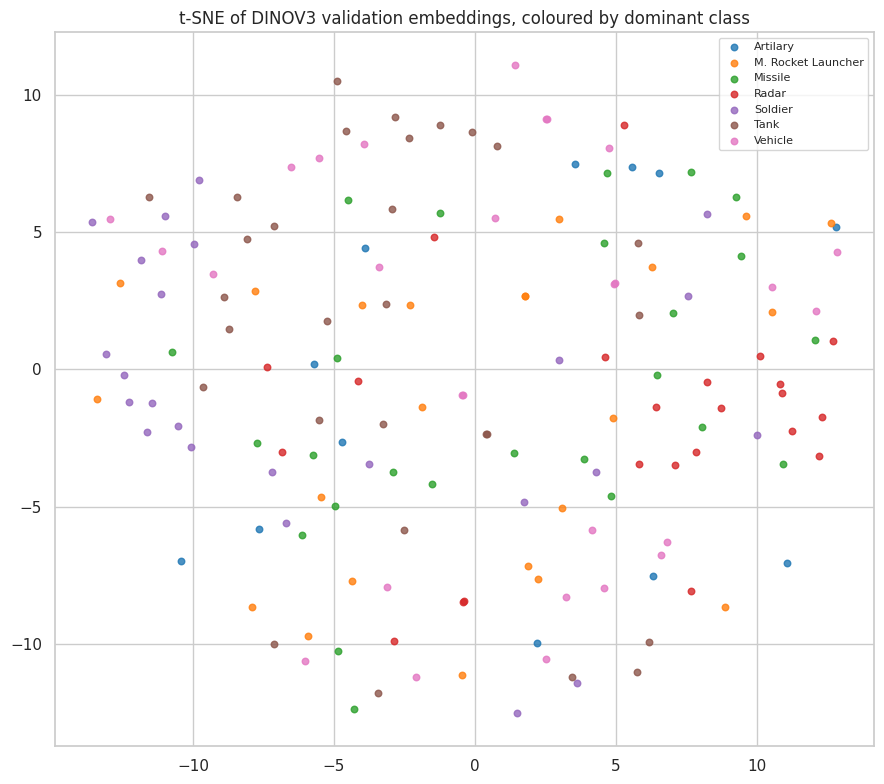

In [13]:
def dominant_class_for_stem(stem, labels_dir):
    lbl_path = Path(labels_dir) / f"{stem}.txt"
    counts = Counter()
    if lbl_path.exists():
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    counts[int(float(parts[0]))] += 1
    return CLASS_NAMES[counts.most_common(1)[0][0]] if counts else "No Label"

val_labels_dir = RESPLIT_ROOT / "val" / "labels"
point_classes = [dominant_class_for_stem(p.stem, val_labels_dir) for p in paths]

perplexity = min(30.0, max(2.0, (len(feature_matrix) - 1) / 3))
tsne_xy = TSNE(n_components=2, random_state=SEED, perplexity=perplexity).fit_transform(feature_matrix)

fig, ax = plt.subplots(figsize=(9, 8))
palette = sns.color_palette("tab10", n_colors=len(set(point_classes)))
for color, cls in zip(palette, sorted(set(point_classes))):
    idx = [i for i, c in enumerate(point_classes) if c == cls]
    ax.scatter(tsne_xy[idx, 0], tsne_xy[idx, 1], label=cls, s=22, alpha=0.8, color=color)
ax.legend(fontsize=8, loc="best"); ax.set_title(f"t-SNE of {METHOD.upper()} validation embeddings, coloured by dominant class")
plt.tight_layout(); plt.show()

## 11. Nearest-neighbour retrieval

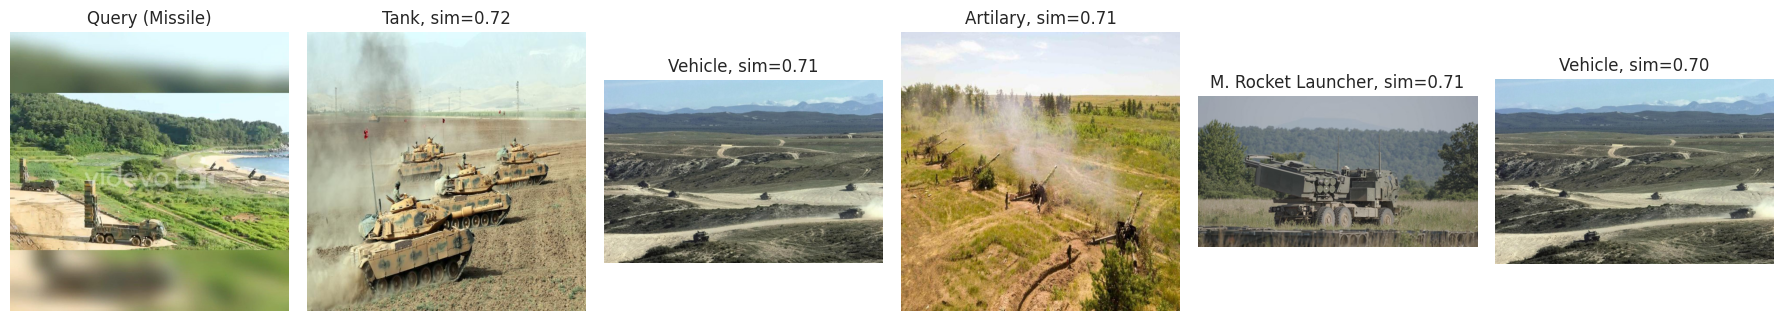

In [14]:
sims = cosine_similarity(feature_matrix)
QUERY_INDEX = 0
NEIGHBOR_COUNT = min(5, len(feature_matrix) - 1)
neighbour_idx = np.argsort(-sims[QUERY_INDEX])[1:NEIGHBOR_COUNT + 1]

fig, axes = plt.subplots(1, NEIGHBOR_COUNT + 1, figsize=(3 * (NEIGHBOR_COUNT + 1), 3.2))
axes[0].imshow(Image.open(paths[QUERY_INDEX]))
axes[0].set_title(f"Query ({point_classes[QUERY_INDEX]})"); axes[0].axis("off")
for ax, idx in zip(axes[1:], neighbour_idx):
    ax.imshow(Image.open(paths[idx])); ax.set_title(f"{point_classes[idx]}, sim={sims[QUERY_INDEX, idx]:.2f}"); ax.axis("off")
plt.tight_layout(); plt.show()

## 12. Shortcut-learning check — raw vs. copy-paste synthetic, on the TRAIN pool

This check needs images that actually include copy-paste synthetics, so it runs on the **train** pool
specifically (not validation, which is always 100% raw and would show only one colour here).


Embedding train-pool images:   0%|          | 0/300 [00:00<?, ?it/s]

Raw: 155 | Copy-paste synthetic: 145


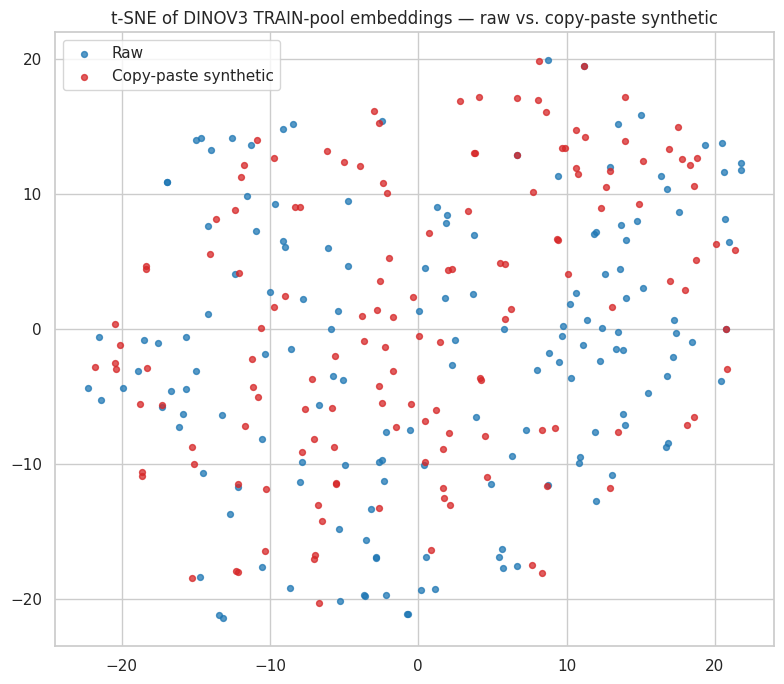

In [15]:
TRAIN_DIAGNOSTIC_LIMIT = 300
train_stem_set_raw = set(stems_train)
train_sample_paths = train_images if len(train_images) <= TRAIN_DIAGNOSTIC_LIMIT else random.Random(SEED).sample(train_images, TRAIN_DIAGNOSTIC_LIMIT)

train_feats, train_is_synthetic = [], []
with torch.inference_mode():
    for p in tqdm(train_sample_paths, desc="Embedding train-pool images"):
        x = infer_tf(Image.open(p).convert("RGB")).unsqueeze(0).to(DEVICE)
        feat = torch.nn.functional.normalize(encoder(x).flatten(1), dim=1)
        train_feats.append(feat.squeeze(0).cpu().numpy())
        train_is_synthetic.append(p.stem not in train_stem_set_raw)

train_feature_matrix = np.stack(train_feats)
print("Raw:", train_is_synthetic.count(False), "| Copy-paste synthetic:", train_is_synthetic.count(True))

perplexity_train = min(30.0, max(2.0, (len(train_feature_matrix) - 1) / 3))
tsne_train_xy = TSNE(n_components=2, random_state=SEED, perplexity=perplexity_train).fit_transform(train_feature_matrix)

fig, ax = plt.subplots(figsize=(8, 7))
for flag, label, color in [(False, "Raw", "tab:blue"), (True, "Copy-paste synthetic", "tab:red")]:
    idx = [i for i, s in enumerate(train_is_synthetic) if s == flag]
    ax.scatter(tsne_train_xy[idx, 0], tsne_train_xy[idx, 1], label=label, s=18, alpha=0.75, c=color)
ax.legend(); ax.set_title(f"t-SNE of {METHOD.upper()} TRAIN-pool embeddings — raw vs. copy-paste synthetic")
plt.tight_layout(); plt.show()

## 13. Quantitative collapse diagnostics — beyond eyeballing one query

Same rigorous test used for SimCLR/BYOL/I-JEPA. DINOv3 distils from an already-strong frozen teacher, so
a healthy, spread-out representation is expected here even more strongly than for the from-scratch
methods — if this still shows a collapse signature, that would be a surprising, noteworthy result.


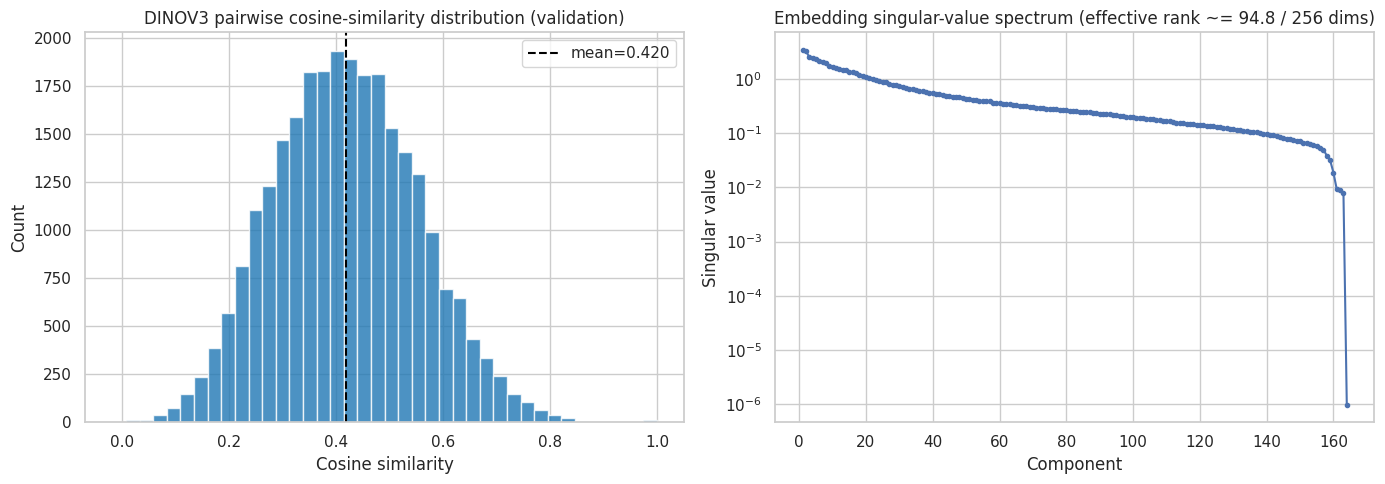

mean pairwise similarity                                       0.4198
std pairwise similarity                                        0.1353
effective rank                                                  94.82
embedding dimensionality                                          256
collapse read               no strong collapse signature by this test
dtype: object

In [16]:
pairwise_sims = cosine_similarity(feature_matrix)
off_diagonal = pairwise_sims[~np.eye(len(pairwise_sims), dtype=bool)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(off_diagonal, bins=40, color="tab:blue", alpha=0.8)
axes[0].axvline(off_diagonal.mean(), color="black", linestyle="--", label=f"mean={off_diagonal.mean():.3f}")
axes[0].set_title(f"{METHOD.upper()} pairwise cosine-similarity distribution (validation)")
axes[0].set_xlabel("Cosine similarity"); axes[0].set_ylabel("Count"); axes[0].legend()

singular_values = np.linalg.svd(feature_matrix - feature_matrix.mean(axis=0), compute_uv=False)
normalized_sv = singular_values / singular_values.sum()
effective_rank = float(np.exp(-(normalized_sv * np.log(normalized_sv + 1e-12)).sum()))
axes[1].plot(range(1, len(singular_values) + 1), singular_values, marker="o", markersize=3)
axes[1].set_title(f"Embedding singular-value spectrum (effective rank ~= {effective_rank:.1f} / {feature_matrix.shape[1]} dims)")
axes[1].set_xlabel("Component"); axes[1].set_ylabel("Singular value"); axes[1].set_yscale("log")
plt.tight_layout(); plt.show()

pd.Series({
    "mean pairwise similarity": round(float(off_diagonal.mean()), 4),
    "std pairwise similarity": round(float(off_diagonal.std()), 4),
    "effective rank": round(effective_rank, 2),
    "embedding dimensionality": feature_matrix.shape[1],
    "collapse read": ("LIKELY COLLAPSED - similarities tightly clustered near 1.0 and/or effective rank very low"
                       if off_diagonal.mean() > 0.9 and off_diagonal.std() < 0.05
                       else "no strong collapse signature by this test"),
})

## 14. Exercise — random-init student vs. COCO-pretrained-init student

The reference tutorial's own suggested exercise: create a second run starting the **student** from
`ultralytics/yolo26n.pt` (COCO-pretrained) instead of `ultralytics/yolo26n.yaml` (random init), keeping
the DINOv3 teacher and every other setting identical.

**Prediction before running:** a COCO-pretrained student already has generically useful convolutional
features before distillation even starts, so it should converge faster and likely reach a
higher-quality representation than a student starting from nothing — similar in spirit to how
COCO-pretrained massively outperforms random-init in every downstream detect notebook so far. Unlike
that downstream comparison though, here it interacts with the *distillation* objective rather than
supervised detection loss, so the size of the effect (if any) is worth checking rather than assuming.

In [17]:
exercise_config = DINOv3YOLOConfig(**{
    **config.to_dict(),
    "student_model": "ultralytics/yolo26n.pt",
    "epochs": 50,
    "output_dir": f"/kaggle/working/{METHOD}_kiitmita_coco_student",
}).validate()

pd.Series({
    "student": exercise_config.student_model, "teacher": exercise_config.teacher_model,
    "epochs": exercise_config.epochs, "output directory": exercise_config.output_dir,
})

student                                   ultralytics/yolo26n.pt
teacher                                            dinov3/vitb16
epochs                                                        50
output directory    /kaggle/working/dinov3_kiitmita_coco_student
dtype: object

In [18]:
exercise_result = pretrain_dinov3_yolo26(exercise_config, module=lightly_train)
exercise_result

Args: {
    "accelerator": "gpu",
    "batch_size": 32,
    "callbacks": null,
    "checkpoint": null,
    "data": "/kaggle/input/notebooks/arifulislamopi/group02-dataset-eda/dataset-resplit/train/images",
    "devices": 1,
    "embed_dim": null,
    "epochs": 50,
    "float32_matmul_precision": "auto",
    "loader_args": null,
    "loggers": null,
    "method": "distillation",
    "method_args": {
        "teacher": "dinov3/vitb16",
        "teacher_weights": "/kaggle/input/datasets/mrifatrashid/dinov3-weigths/dinov3_vitb16_pretrain_lvd1689m-73cec8be.pth"
    },
    "model": "ultralytics/yolo26n.pt",
    "model_args": null,
    "num_nodes": 1,
    "num_workers": 2,
    "optim": "adamw",
    "optim_args": {
        "betas": [
            0.9,
            0.999
        ],
        "eps": 1e-08,
        "lr": 0.0003,
        "weight_decay": 0.0001
    },
    "out": "/kaggle/working/dinov3_kiitmita_coco_student",
    "overwrite": true,
    "precision": "16-mixed",
    "resume": null,
    "

Enabling gradients for parameter 'model.model.0.conv.weight'
Enabling gradients for parameter 'model.model.0.bn.weight'
Enabling gradients for parameter 'model.model.0.bn.bias'
Enabling gradients for parameter 'model.model.1.conv.weight'
Enabling gradients for parameter 'model.model.1.bn.weight'
Enabling gradients for parameter 'model.model.1.bn.bias'
Enabling gradients for parameter 'model.model.2.cv1.conv.weight'
Enabling gradients for parameter 'model.model.2.cv1.bn.weight'
Enabling gradients for parameter 'model.model.2.cv1.bn.bias'
Enabling gradients for parameter 'model.model.2.cv2.conv.weight'
Enabling gradients for parameter 'model.model.2.cv2.bn.weight'
Enabling gradients for parameter 'model.model.2.cv2.bn.bias'
Enabling gradients for parameter 'model.model.2.m.0.cv1.conv.weight'
Enabling gradients for parameter 'model.model.2.m.0.cv1.bn.weight'
Enabling gradients for parameter 'model.model.2.m.0.cv1.bn.bias'
Enabling gradients for parameter 'model.model.2.m.0.cv2.conv.weight

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.
Training completed.
Example: How to use the exported model
----------------------------------------------------------------------------------------
from ultralytics import YOLO

# Load the pretrained model
model = YOLO('/kaggle/working/dinov3_kiitmita_coco_student/exported_models/exported_last.pt')

# Finetune or evaluate the model
...
----------------------------------------------------------------------------------------

Model exported.


DINOv3YOLOResult(output_dir=PosixPath('/kaggle/working/dinov3_kiitmita_coco_student'), training_checkpoint=PosixPath('/kaggle/working/dinov3_kiitmita_coco_student/checkpoints/last.ckpt'), yolo_checkpoint=PosixPath('/kaggle/working/dinov3_kiitmita_coco_student/exported_models/exported_last.pt'), metrics_jsonl=PosixPath('/kaggle/working/dinov3_kiitmita_coco_student/metrics.jsonl'), teacher_model='dinov3/vitb16', teacher_weights=PosixPath('/kaggle/input/datasets/mrifatrashid/dinov3-weigths/dinov3_vitb16_pretrain_lvd1689m-73cec8be.pth'), student_model='ultralytics/yolo26n.pt')

Feature extraction on the *same* validation images as the main run, for a fair comparison.

In [19]:
exercise_encoder = YOLOBackboneEncoder(YOLO(str(exercise_result.yolo_checkpoint)).model).to(DEVICE).eval()

exercise_feats = []
with torch.inference_mode():
    for p in tqdm(selected_paths, desc="Embedding val images (COCO-init student)"):
        x = infer_tf(Image.open(p).convert("RGB")).unsqueeze(0).to(DEVICE)
        feat = torch.nn.functional.normalize(exercise_encoder(x).flatten(1), dim=1)
        exercise_feats.append(feat.squeeze(0).cpu().numpy())
exercise_feature_matrix = np.stack(exercise_feats)

Embedding val images (COCO-init student):   0%|          | 0/164 [00:00<?, ?it/s]

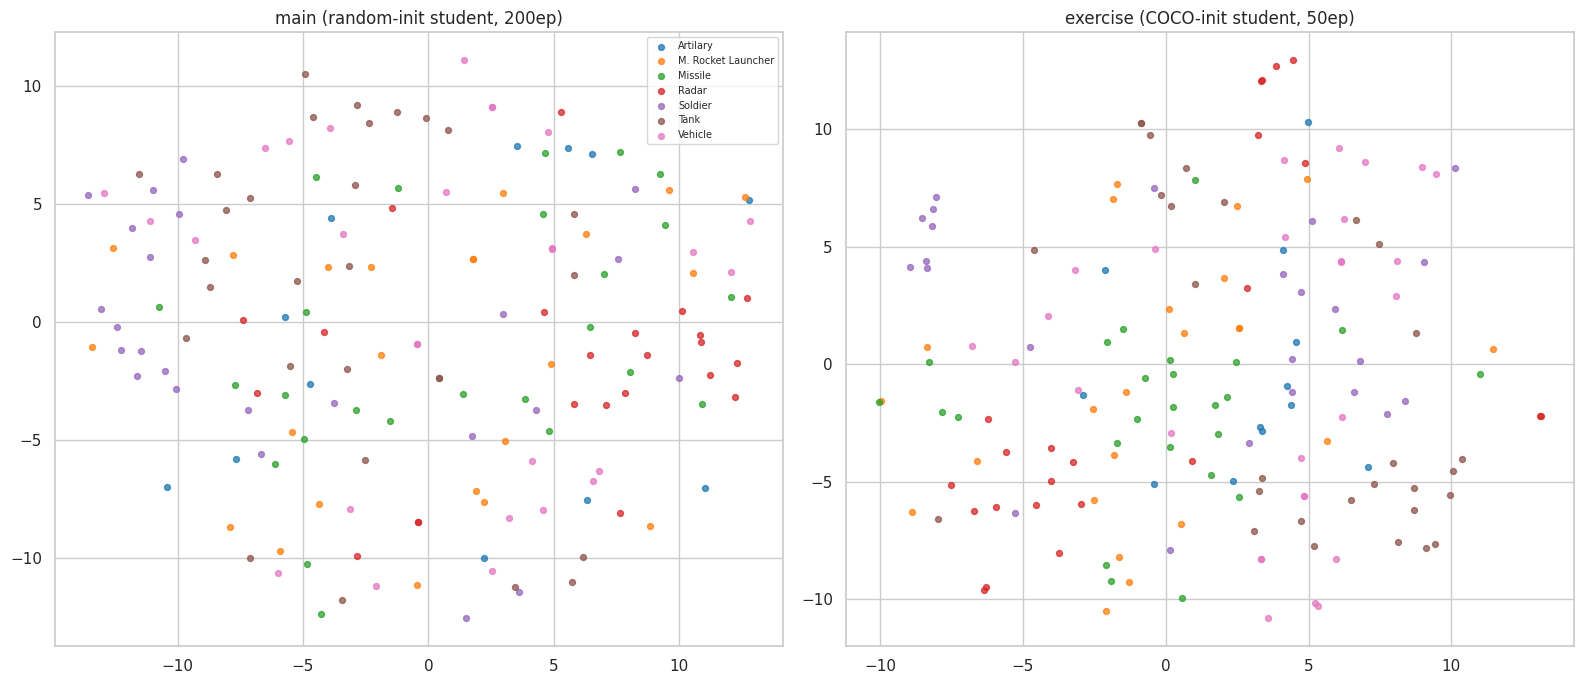

In [20]:
tsne_main = TSNE(n_components=2, random_state=SEED, perplexity=perplexity).fit_transform(feature_matrix)
tsne_exercise = TSNE(n_components=2, random_state=SEED, perplexity=perplexity).fit_transform(exercise_feature_matrix)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, xy, title in [(axes[0], tsne_main, "main (random-init student, 200ep)"),
                       (axes[1], tsne_exercise, "exercise (COCO-init student, 50ep)")]:
    for color, cls in zip(palette, sorted(set(point_classes))):
        idx = [i for i, c in enumerate(point_classes) if c == cls]
        ax.scatter(xy[idx, 0], xy[idx, 1], label=cls, s=18, alpha=0.75, color=color)
    ax.set_title(title)
axes[0].legend(fontsize=7)
plt.tight_layout(); plt.show()

In [21]:
def collapse_stats(fm):
    sims = cosine_similarity(fm)
    off = sims[~np.eye(len(sims), dtype=bool)]
    sv = np.linalg.svd(fm - fm.mean(axis=0), compute_uv=False)
    p = sv / sv.sum()
    eff_rank = float(np.exp(-(p * np.log(p + 1e-12)).sum()))
    return off.mean(), off.std(), eff_rank

mean_main, std_main, rank_main = collapse_stats(feature_matrix)
mean_ex, std_ex, rank_ex = collapse_stats(exercise_feature_matrix)

pd.DataFrame({
    "main (random-init student, 200ep)": [mean_main, std_main, rank_main],
    "exercise (COCO-init student, 50ep)": [mean_ex, std_ex, rank_ex],
}, index=["mean pairwise similarity", "std pairwise similarity", "effective rank"]).round(4)

,"main (random-init student, 200ep)","exercise (COCO-init student, 50ep)"
mean pairwise similarity,0.4198,0.7384
std pairwise similarity,0.1353,0.0754
effective rank,94.8236,102.6410


## 16. Publish the checkpoint for Notebook 4b


In [22]:
print("Attach this notebook as a Kaggle input to Notebook 4b.")
print("YOLO checkpoint (already detector-ready, no weight-surgery needed):", YOLO_CHECKPOINT)

Attach this notebook as a Kaggle input to Notebook 4b.
YOLO checkpoint (already detector-ready, no weight-surgery needed): /kaggle/working/dinov3_kiitmita/exported_models/exported_last.pt
